In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/online_retail_II.csv',encoding='ISO-8859-1')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df.shape

(541910, 8)

#DATA CLEANING

In [ ]:
# Check nulls
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [ ]:
df = df.dropna(subset=['Customer ID'])

In [ ]:
# Remove canceled orders (Invoice starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [ ]:
# Remove negative/zero quantities
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [ ]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

/tmp/ipython-input-209/1785568889.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [ ]:
# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397885 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      397885 non-null  object        
 1   StockCode    397885 non-null  object        
 2   Description  397885 non-null  object        
 3   Quantity     397885 non-null  int64         
 4   InvoiceDate  397885 non-null  datetime64[ns]
 5   Price        397885 non-null  float64       
 6   Customer ID  397885 non-null  float64       
 7   Country      397885 non-null  object        
 8   TotalPrice   397885 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
TotalPrice,0


**Our data has no outliers and missing values, so it is cleaned and set**

**REVENUE OVER TIME**

Text(0, 0.5, 'Revenue in GBP (£)')

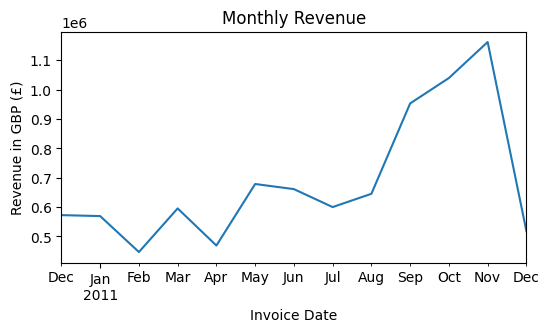

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum().plot(figsize=(6,3))
plt.title("Monthly Revenue")
plt.xlabel("Invoice Date")
plt.ylabel("Revenue in GBP (£)")


The dataset spans from December 2010 to December 2011.
Revenue shows a strong peak toward the end of 2011, indicating seasonal demand during the holiday period.
A noticeable decline is observed at the beginning of 2011, reflecting post-holiday slowdown.

## **Top 10 Countries by Revenue**


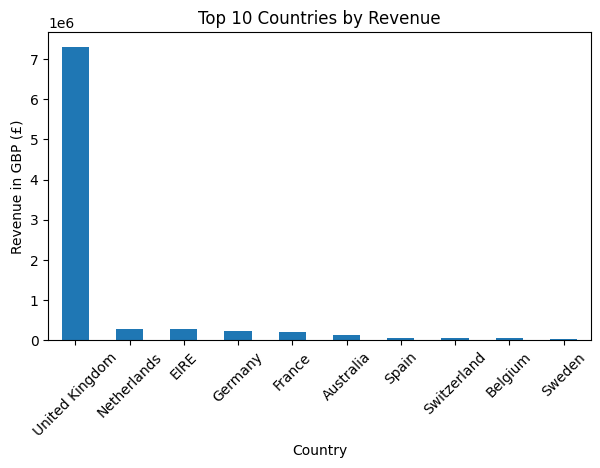

In [ ]:
country_revenue = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

# Plot
country_revenue.head(10).plot(kind="bar", figsize=(7,4))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue in GBP (£)")
plt.xticks(rotation=45)
plt.show()

The business is overwhelmingly UK-centric, with other countries representing only a very small fraction of its total revenue.

**TOP 10 BY REVENUE**

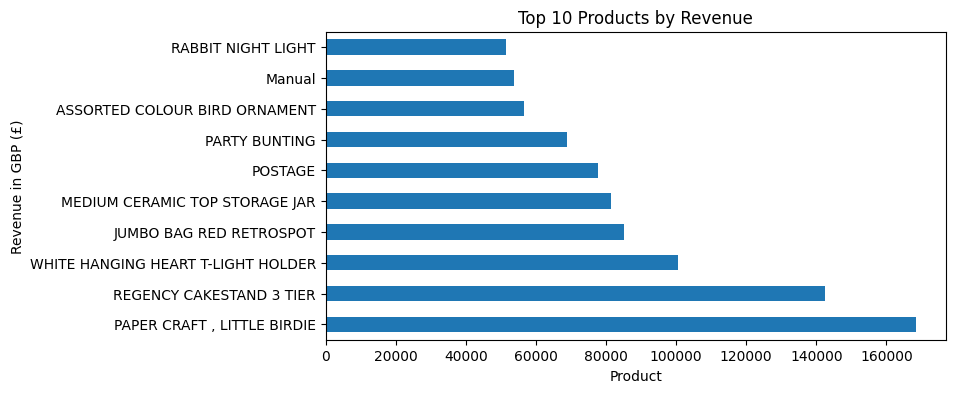

In [ ]:
# Group revenue by product description
top_products = (
    df.groupby("Description")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

# Plot Top 10 Products
top_products.head(10).plot(kind="barh", figsize=(8,4))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue in GBP (£)")
plt.show()

**“PAPER CRAFT, LITTLE BIRDIE”** generates the highest revenue, making it the most valuable product for the business.

**“REGENCY CAKESTAND 3 TIER”**  is the second highest revenue contributor, indicating strong customer demand.

Decorative and gift-related items (like hanging lights and party items) appear multiple times

Revenue distribution shows that a small number of products contribute a large portion of total revenue.

**Revenue by week**

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Wednesday'),
  Text(1, 0, 'Thursday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Sunday'),
  Text(4, 0, 'Monday'),
  Text(5, 0, 'Tuesday')])

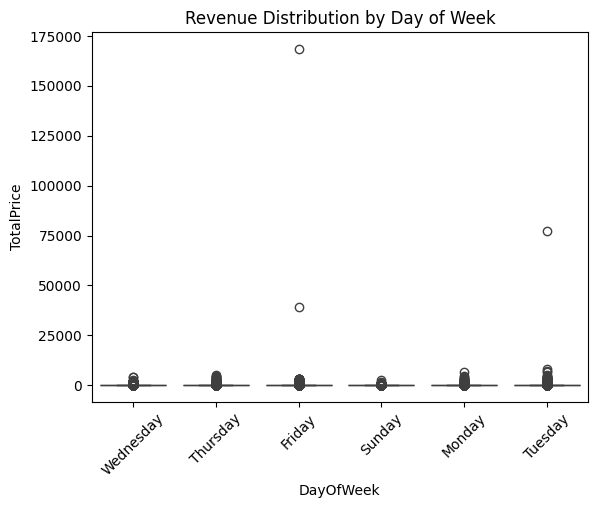

In [ ]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
sns.boxplot(x="DayOfWeek", y="TotalPrice", data=df)
plt.title("Revenue Distribution by Day of Week")
plt.xticks(rotation=45)


**Customer by Revenue**

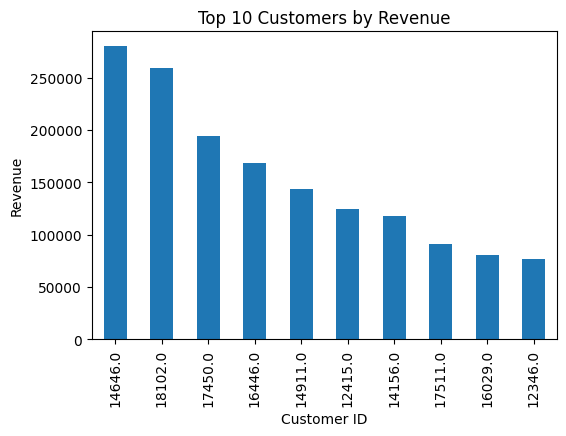

In [ ]:
top_customers = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(kind="bar", figsize=(6,4), title="Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

The analysis reveals that revenue is highly concentrated among a small group of customers. The top customers contribute a disproportionately large share of total revenue, indicating strong dependency on high-value clients. This suggests the need for targeted retention strategies and personalized engagement to maintain business stability.

# **Customer Segmentation using RFM Analysis**

In [ ]:
import datetime as dt
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Invoice": "nunique",                                  # Frequency
    "TotalPrice": "sum"                                       # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R_score"].astype(str) + \
                   rfm["F_score"].astype(str) + \
                   rfm["M_score"].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


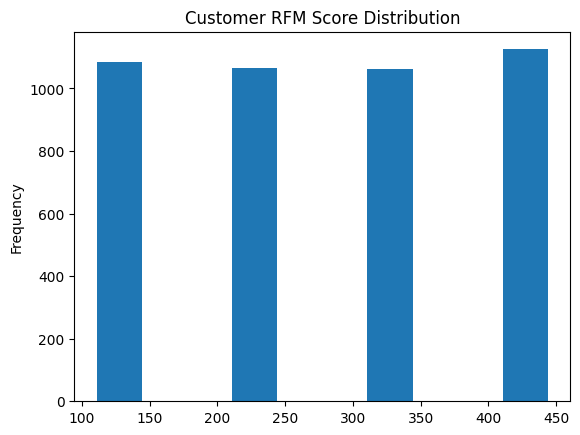

In [ ]:
rfm["RFM_Score"].astype(int).plot(kind='hist', bins=10, title="Customer RFM Score Distribution");

RFM scores are evenly distributed across customer groups, indicating a balanced segmentation approach based on quartile scoring.

In [ ]:
def segment(row):
    if row["RFM_Score"] == "444":
        return "Champions"
    elif row["F_score"] == 4 and row["M_score"] == 4:
        return "Loyal Customers"
    elif row["R_score"] == 4:
        return "Recent Customers"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)

rfm["Segment"].value_counts()

,count
Segment,
Others,2892
Recent Customers,635
Champions,490
Loyal Customers,321


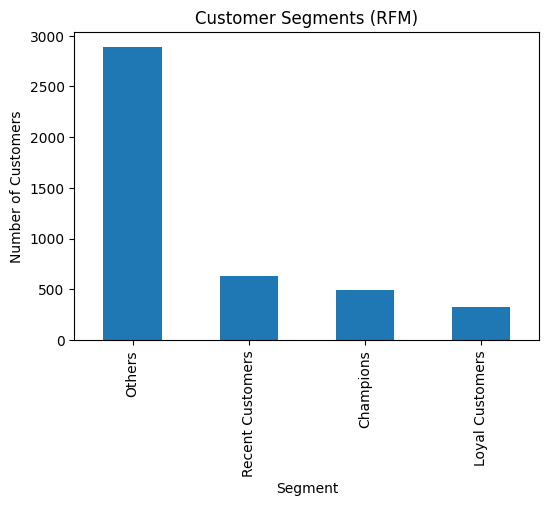

In [ ]:
rfm["Segment"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Customer Segments (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

The majority of customers fall under the “Others” segment, while a smaller group of Champions and Loyal Customers contribute significantly to revenue. This suggests an opportunity to improve retention strategies and increase engagement among mid-tier customers.